# Title

In [ ]:
# Importing necessary modules for analysis
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [8]:
# Loading csv file into data frame
mcdavid_df = pd.read_csv('../data/mcdavid_game_log.csv')
mcdavid_df.head(10)

,date,opponent,goals,assists,points,plus_minus,SOG,TOI,result,team_score,opp_score,game_number,game_context,season
0,2024-06-08,FLA,0,0,0,-2,6.0,25:19,L,0,3,1.0,stanley_cup_finals,2023-24
1,2024-06-10,FLA,0,1,1,1,3.0,25:59,L,1,4,2.0,stanley_cup_finals,2023-24
2,2024-06-13,FLA,0,2,2,1,5.0,25:14,L,3,4,3.0,stanley_cup_finals,2023-24
3,2024-06-15,FLA,1,3,4,2,2.0,17:27,W,8,1,4.0,stanley_cup_finals,2023-24
4,2024-06-18,FLA,2,2,4,2,2.0,24:37,W,5,3,5.0,stanley_cup_finals,2023-24
5,2024-06-21,FLA,0,0,0,1,0.0,18:58,W,5,1,6.0,stanley_cup_finals,2023-24
6,2024-06-24,FLA,0,0,0,0,2.0,25:42,L,1,2,7.0,stanley_cup_finals,2023-24
7,2025-06-04,FLA,0,2,2,0,4.0,31:12,W,4,3,1.0,stanley_cup_finals,2024-25
8,2025-06-06,FLA,0,3,3,0,7.0,35:07,L,4,5,2.0,stanley_cup_finals,2024-25
9,2025-06-09,FLA,0,0,0,-1,2.0,20:51,L,1,6,3.0,stanley_cup_finals,2024-25


In [12]:
# Convert date to datetime
mcdavid_df['date'] = pd.to_datetime(mcdavid_df['date'])

# Convert TOI from "MM:SS" string to float minutes
mcdavid_df[['minutes_TOI', 'seconds_TOI']] = mcdavid_df['TOI'].str.split(':', expand= True)
mcdavid_df['TOI'] = mcdavid_df['minutes_TOI'].astype(float) + (mcdavid_df['seconds_TOI'].astype(int) / 60)
mcdavid_df = mcdavid_df.drop(columns=['minutes_TOI', 'seconds_TOI'])

# Convert game_number from float64 to a nullable integer type
mcdavid_df['game_number'] = mcdavid_df['game_number'].astype('Int64')

In [ ]:
# Saving cleaned df as a csv
mcdavid_df.to_csv('../data/mcdavid_game_log_clean.csv', index=False)

## Analysis

This analysis is structured in three acts, each representing a 
distinct competitive context that together tell the complete story 
of Connor McDavid in high stakes hockey.

**Act 1** examines McDavid's performance in the NHL Stanley Cup 
Playoffs — his home stage and the ultimate measure of hockey 
greatness.

**Act 2** examines the 2025 Four Nations Face-Off — the first test 
with an elite supporting cast, and the tournament he won.

**Act 3** examines the 2026 Winter Olympics — the same elite roster, 
a different result, and the question of what changed.

## Act 1: The Stanley Cup Playoffs
### Does McDavid underperform when it matters most and are the Oilers doing enough around him?

### 1.1 Average Points by Game Context

In [ ]:
mcdavid_df = pd.read_csv('../data/mcdavid_game_log_clean.csv')

nhl_contexts = [
    'regular_season',
    'first_round', 
    'second_round',
    'conf_finals',
    'stanley_cup_finals'
]

nhl_df = mcdavid_df[mcdavid_df['game_context'].isin(nhl_contexts)]

nhl_context_avg = nhl_df.groupby('game_context')[['goals', 'assists', 
                  'points', 'plus_minus', 'team_score']].mean().round(2)

nhl_order = [
    'regular_season',
    'first_round',
    'second_round', 
    'conf_finals',
    'stanley_cup_finals'
]

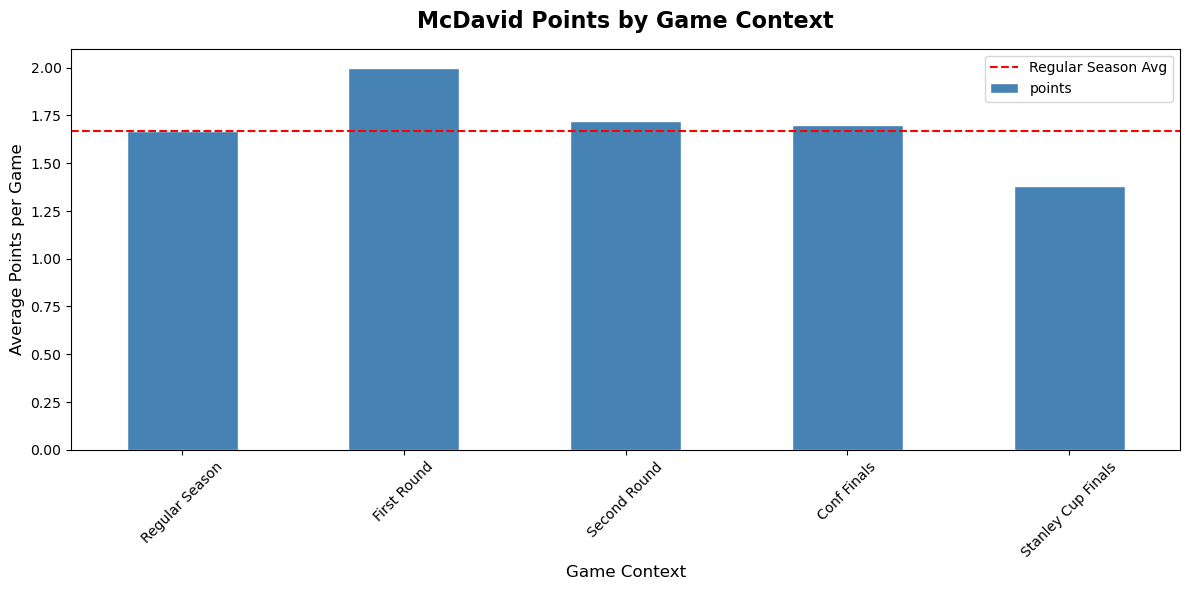

In [102]:
nhl_context_avg.reindex(nhl_order)

fig, ax = plt.subplots(figsize=(12, 6))

nhl_context_avg.reindex(nhl_order)['points'].plot(
    kind='bar',
    ax=ax,
    color='steelblue',
    edgecolor='white'
)

ax.set_title('McDavid Points by Game Context', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Game Context', fontsize=12)
ax.set_ylabel('Average Points per Game', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.axhline(y=nhl_context_avg.loc['regular_season', 'points'], 
           color='red', linestyle='--', linewidth=1.5, 
           label='Regular Season Avg')
ax.legend()

plt.tight_layout()
ax.set_xticklabels([label.get_text().replace('_', ' ').title() 
                    for label in ax.get_xticklabels()])
plt.show()

### Interpretation
McDavid's average points per game remain at or above his regular season benchmark of 1.67 points per game. McDavid peaks in the first round of the Stanley Cup Playoffs but then he falls to his lowest points per game average during the Stanley Cup Finals, quite possible the worst round to decline. This adds to the narrative that McDavid can't seem to perform on the biggest stage of hockey. But is this really a fair conclusion considering we are only measuring points per game as an offensive metric? But points alone don't tell the full story, the next metric reveals something more troubling about what happens to the Oilers as a team when the stakes are highest.

### 1.2 Average Plus/Minus by Game Context

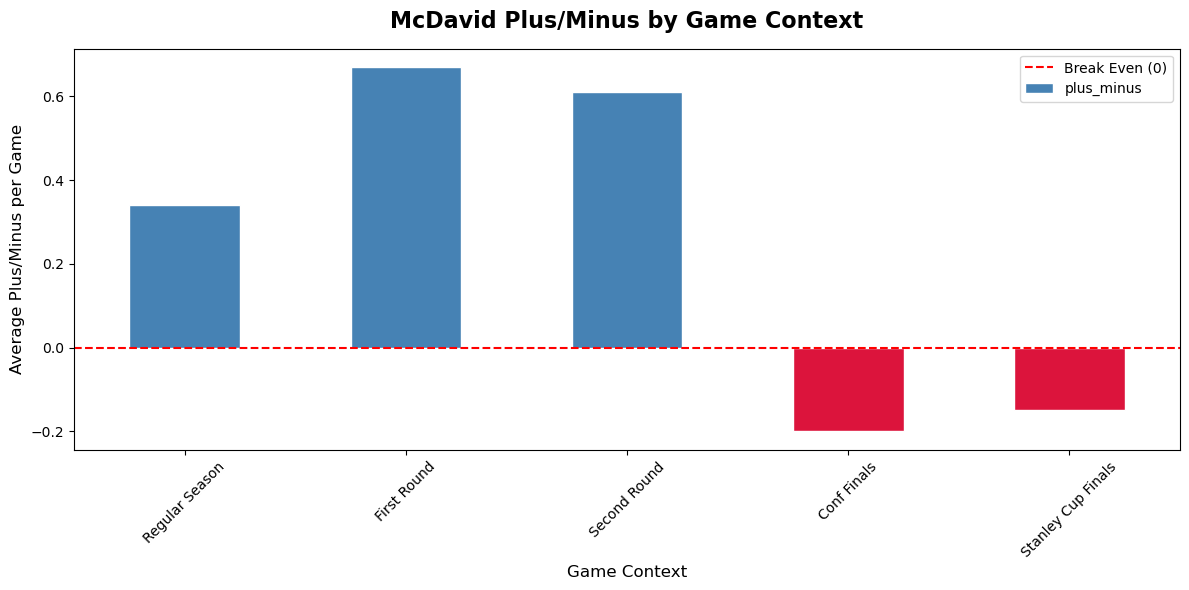

In [103]:
colors = ['steelblue' if val >= 0 else 'crimson' 
          for val in nhl_context_avg.reindex(nhl_order)['plus_minus']]

fig, ax = plt.subplots(figsize=(12, 6))

nhl_context_avg.reindex(nhl_order)['plus_minus'].plot(
    kind='bar',
    ax=ax,
    color=colors,
    edgecolor='white'
)

ax.set_title('McDavid Plus/Minus by Game Context', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Game Context', fontsize=12)
ax.set_ylabel('Average Plus/Minus per Game', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.axhline(y=0, 
           color='red', linestyle='--', linewidth=1.5, 
           label='Break Even (0)')
ax.legend()

plt.tight_layout()
ax.set_xticklabels([label.get_text().replace('_', ' ').title() 
                    for label in ax.get_xticklabels()])
plt.show()

### Interpretation
The trend is very similar to the previous graph based on average points per game. McDavid is still consistently performing well in the regular season and early rounds of the playoffs resulting in his team winning more often. But the dips occur once again during the later round of the playoffs. Rounds such as the Stanley Cup Conference Finals or the Stanley Cup Finals, the Oilers are consistently getting outscored when he's on the ice in high stakes games, even as he continues to produce points. This raises the question of whether this pattern holds at the individual game level, or whether McDavid has specific elimination games where his performance drops most dramatically.

### 1.3 Elimination Game Analysis

In [107]:
elimination_game_dates = [
    # 2022 - vs Kings
    '2022-05-12', '2022-05-14',
    # 2022 - vs Colorado
    '2022-06-06',
    # 2023 - vs Golden Knights
    '2023-05-14',
    # 2024 - vs Vancouver
    '2024-05-18', '2024-05-20',
    # 2024 - vs Florida
    '2024-06-15', '2024-06-18', '2024-06-21', '2024-06-24',
    # 2025 - vs Florida
    '2025-06-17',
]

mcdavid_df['date'] = pd.to_datetime(mcdavid_df['date'])
mcdavid_df['is_elimination_game'] = mcdavid_df['date'].dt.strftime('%Y-%m-%d').isin(elimination_game_dates)


# Act 1 - NHL only elimination games
nhl_elimination_df = nhl_df[nhl_df['is_elimination_game'] == True]
nhl_non_elimination_df = nhl_df[nhl_df['is_elimination_game'] == False]

print("=== ELIMINATION GAMES ===")
print(nhl_elimination_df[['goals', 'assists', 'points', 'plus_minus']].mean().round(2))
print()
print("=== NON ELIMINATION GAMES ===")
print(nhl_non_elimination_df[['goals', 'assists', 'points', 'plus_minus']].mean().round(2))

=== ELIMINATION GAMES ===
goals         0.64
assists       1.18
points        1.82
plus_minus    0.91
dtype: float64

=== NON ELIMINATION GAMES ===
goals         0.53
assists       1.14
points        1.67
plus_minus    0.32
dtype: float64


In [108]:
print("=== ELIMINATION GAMES - LOSSES (Season ended) ===")
print(nhl_elimination_df[nhl_elimination_df['result'] == 'L'][['goals', 'assists', 'points', 'plus_minus']].mean().round(2))
print()
print("=== ELIMINATION GAMES - WINS (Survived) ===")
print(nhl_elimination_df[nhl_elimination_df['result'] == 'W'][['goals', 'assists', 'points', 'plus_minus']].mean().round(2))

=== ELIMINATION GAMES - LOSSES (Season ended) ===
goals         0.33
assists       0.67
points        1.00
plus_minus   -1.00
dtype: float64

=== ELIMINATION GAMES - WINS (Survived) ===
goals         1.00
assists       1.67
points        2.67
plus_minus    1.67
dtype: float64


### Hypothesis
Based on the trend and what we have seen so far from points per game and plus/minus based on the game context, it's likely that McDavid's averages in elimination games are much lower than non elimination games. 

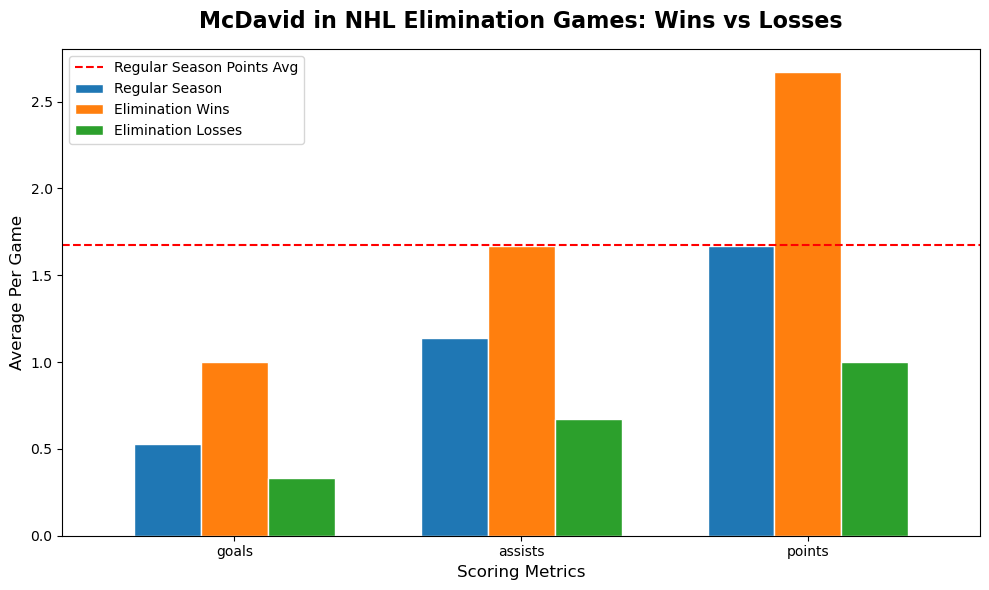

In [109]:
nhl_comparison_data = pd.DataFrame({
    'Regular Season': nhl_non_elimination_df[['goals', 'assists', 'points']].mean().round(2),
    'Elimination Wins': nhl_elimination_df[nhl_elimination_df['result'] == 'W'][['goals', 'assists', 'points']].mean().round(2),
    'Elimination Losses': nhl_elimination_df[nhl_elimination_df['result'] == 'L'][['goals', 'assists', 'points']].mean().round(2)
})

fig, ax = plt.subplots(figsize=(10, 6))

nhl_comparison_data.plot(
    kind='bar',
    ax=ax,
    edgecolor='white',
    width=0.7
)

ax.set_title('McDavid in NHL Elimination Games: Wins vs Losses', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Scoring Metrics', fontsize=12)
ax.set_ylabel('Average Per Game', fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.axhline(y=nhl_non_elimination_df['points'].mean(),
           color='red', linestyle='--', linewidth=1.5,
           label='Regular Season Points Avg')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

### Interpretation
The graph is telling in of itself, McDavid is still able to perform in these elimination games. However there is one interesting thing to analyze, that being the noticeable drop from McDavid's 
performance in the regular season vs elimination losses. It's worth noting the sample size difference, hundreds of regular season games versus a handful of elimination losses, but for a player of McDavid's caliber, even a small sample of season-ending performances carries significant weight. Still though, if we're talking about the greatest hockey player on the planet, it doesn't matter how big of a sample size, McDavid should be able to perform in high pressure games, but the numbers are suggesting that he just cannot under these specific conditions. This is directly juxtaposed with his numbers in elimination wins (elimination games where McDavid and the Oilers win to force another game), where McDavid's numbers actually surpass even his regular season numbers where we consider him to be at his best right now. So why? Why is McDavid still falling short when we know that he can perform in the postseason as his numbers actually increase in moments of pressure where his team pulls through? Could there be confounds that we just haven't analyzed yet? Potential factors include opponent goaltending quality, defensive systems specifically designed to neutralize McDavid, and the supporting cast around him in critical moments, all of which we will examine in subsequent analyses.

### 1.4 Performance Trends Within a Series

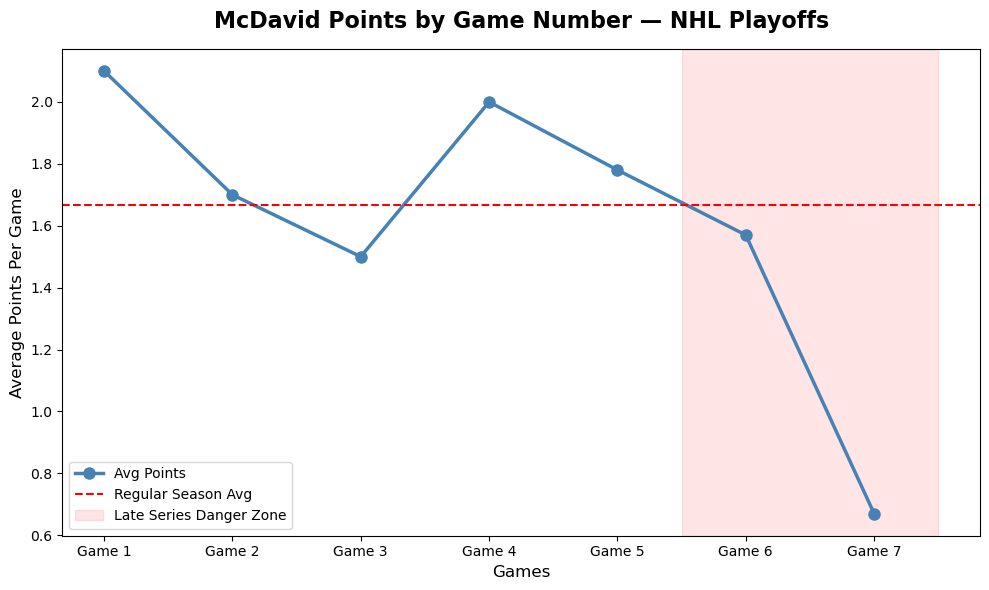

In [113]:
# Act 1 - Series Progression (NHL only)
nhl_series_df = nhl_df[nhl_df['game_number'].notna()]
game_num_avg = nhl_series_df.groupby('game_number')[['points', 'goals', 'assists']].mean().round(2)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(game_num_avg.index, game_num_avg['points'],
        marker='o', linewidth=2.5, color='steelblue',
        markersize=8, label='Avg Points')

ax.axhline(y=nhl_df[nhl_df['game_context'] == 'regular_season']['points'].mean(),
           color='red', linestyle='--', linewidth=1.5,
           label='Regular Season Avg')

ax.axvspan(5.5, 7.5, alpha=0.1, color='red',
           label='Late Series Danger Zone')

ax.set_title('McDavid Points by Game Number — NHL Playoffs', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Games', fontsize=12)
ax.set_ylabel('Average Points Per Game', fontsize=12)

ax.set_xticks([1, 2, 3, 4, 5, 6, 7])
ax.set_xticklabels(['Game 1', 'Game 2', 'Game 3', 'Game 4',
                    'Game 5', 'Game 6', 'Game 7'])

ax.legend()
plt.tight_layout()
plt.show()

### Interpretation 
McDavid averaged approximately 1.67 points per game during the regular season which we used as the baseline of his performance for this graph. As the graph visualizes, McDavid is actually playing better than or right at his regular season benchmark for average points per game when it comes to games 1, 2, 3, 4, and 5. He is consistently showing up for the Oilers and establishing his dominance in the postseason. However, a steep crash occurs right after Game 5 leading into Game 6. The most alarming thing about this is the fact that it isnt just a gradual decline but rather an entire crash. This implies that during the later stages of a 7 game series, Games 6 and 7, McDavid doesn't just play slightly worse than he did in the earlier games, he flat out just disappears during Games 6 and 7. For a player widely considered one of the greatest to ever lace skates, even a small sample of Game 7 performances carries narrative weight. But based on this most recent graph along with the graph of elimination wins/losses, it seems like this is contributing to the overall narrative that McDavid just cannot seem to make a strong impact in the later, higher stakes, games of a 7 game series. The next question becomes more specific, in these high stakes games, how does McDavid's offensive output compare in terms of goals and assists to the Oilers' total team goals? Could it really be the team construction of the Edmonton Oilers that fails McDavid as opposed to McDavid being a non factor?

### 4. Goals vs Assists: The Captain's Burden

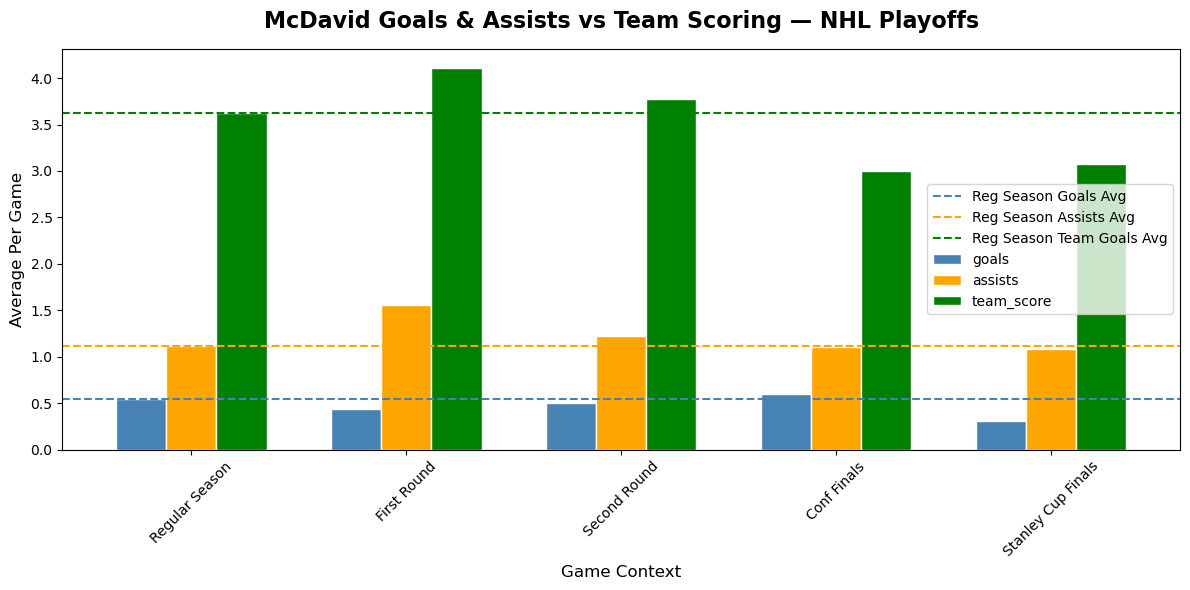

In [112]:
reg_season_goals = nhl_context_avg.loc['regular_season', 'goals']
reg_season_assists = nhl_context_avg.loc['regular_season', 'assists']
reg_season_team_goals = nhl_context_avg.loc['regular_season', 'team_score']

reindexed_nhl_avg = nhl_context_avg.reindex(nhl_order)[['goals', 'assists', 'team_score']]

fig, ax = plt.subplots(figsize=(12, 6))

reindexed_nhl_avg.plot(
    kind='bar',
    ax=ax,
    edgecolor='white',
    width=0.7,
    color=['steelblue', 'orange', 'green']
)

ax.set_title('McDavid Goals & Assists vs Team Scoring — NHL Playoffs', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Game Context', fontsize=12)
ax.set_ylabel('Average Per Game', fontsize=12)
ax.tick_params(axis='x', rotation=45)

ax.axhline(y=reg_season_goals,
           color='steelblue', linestyle='--', linewidth=1.5,
           label='Reg Season Goals Avg')
ax.axhline(y=reg_season_assists,
           color='orange', linestyle='--', linewidth=1.5,
           label='Reg Season Assists Avg')
ax.axhline(y=reg_season_team_goals,
           color='green', linestyle='--', linewidth=1.5,
           label='Reg Season Team Goals Avg')

ax.set_xticklabels([label.get_text().replace('_', ' ').title()
                    for label in ax.get_xticklabels()])
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation 
Based on the plot we see a noticeable trend downwards when it comes to the various rounds of the Stanley Cup Playoffs. When looking at the Stanley Cup Playoffs, we see that McDavid's goals and assists numbers hold and even surpass his regular season marks in some rounds, the earlier rounds in particular. Similarly, the Oiler's team goals also hold up and even surpass their regular season mark in particular rounds of the Stanley Cup Playoffs. This suggests that in the earlier rounds of the Stanley Cup Playoffs (First Round and Second Round), McDavid and the Oilers are firing on all offensive metrics, pure dominance against their opponents. However, a noticable decline occurs during the later rounds of the Stanley Cup Playoffs: the Conference Finals and the Stanley Cup Finals. In these rounds, McDavid and the Oilers offensive metrics drop in comparison to their metrics in the earlier rounds. McDavid's numbers have a relative drop but the most noticable and alarming drop in offensive output actually occurs with the Oilers' overall. This directly juxtaposes what we found in earlier parts of this analysis. This isn't entirely a McDavid problem and it actually introduces the team construction as a reason for why McDavid continues to fail at achieving a Stanley Cup. It's basic sports knowledge, even if McDavid is getting systematically shut down due to great defensive scheming, the Oilers have to step up whether it be a secondary weapon like Leon Draisaitl or a wildcard like Evan Bouchard.

## Act 2: The Four Nations Face-Off
### With an elite supporting cast, does McDavid finally deliver?

## Act 3: The 2026 Winter Olympics
### Same roster, different result — what changed?